## Behind The Hit: Exploring Music Popularity

### How do relationships between audio features and song popularity differ across genres?
This project examines how audio features like energy and danceability relate to song popularity, and whether these relationships differ across genres. Prior analyses of this dataset have found weak overall relationships between audio features and popularity. This project analyses whether that weakness is because genre-specific patterns are being hidden when all songs are analysed together.

Research Question: How do relationships between audio features and song popularity differ across genres, and can these differences explain why prior analyses find weak overall relationships?

Audience: This dashboard is designed for aspiring music creators and producers who are interested in understanding how musical elements like energy and danceability influence song performance within specific genres. The goal is to help them make more informed creative decisions by exploring how these relationships vary across pop, rock, and hip-hop.

### Data
The dataset used is a Spotify tracks dataset containing audio features and metadata for songs across multiple genres. It includes variables like track name, artist, genre, popularity score (0–100), danceability, and energy. The dataset is balanced which means that each genre has a comparable number of songs. This allows for fair comparisons across genres without bias from unequal representation.

For this analysis, the dataset is filtered to three representative genres: Pop, Rock, and Hip-Hop. These were selected because they represent distinct musical styles and listener preferences, making genre-based comparisons meaningful. Focusing on three genres also keeps the analysis clear and focused. Including too many genres at once would make it harder to identify and interpret meaningful patterns across categories.

In [93]:
import pandas as pd
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from dash import Dash, html, dcc, Output, Input, callback

### Data Cleaning
Relevant variables were selected and missing values were removed to ensure consistency during analysis. The data cleaning approach was informed by the following Kaggle project: https://www.kaggle.com/code/jalesummak/spotify-track-ranking-project#5.-Data-Cleaning

In [94]:
df = pd.read_csv("dataset.csv")
df = df[['track_name', 'artists', 'track_genre', 'popularity', 'danceability', 'energy']]
df = df.dropna()

## Initial Exploration

### Popularity Distribution
The histogram below shows the distribution of song popularity across the dataset. Most songs have relatively low popularity scores, with fewer songs reaching high popularity levels.

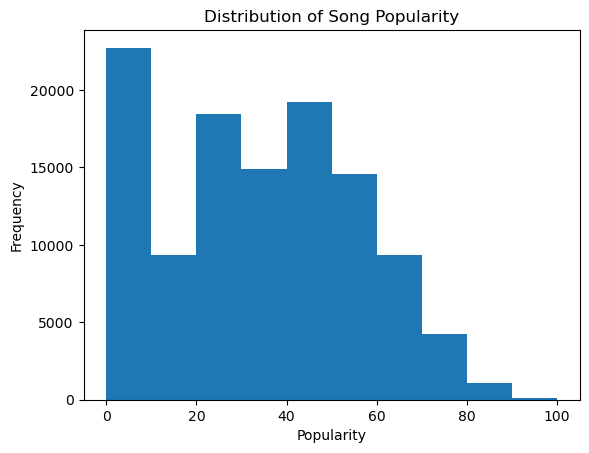

In [95]:
fig, ax = plt.subplots()

ax.hist(df['popularity'])

ax.set_title("Distribution of Song Popularity")
ax.set_xlabel("Popularity")
ax.set_ylabel("Frequency")

plt.show()

### Genre Distribution
The bar chart below shows the number of songs across the top 10 genres. The bars are of similar height, confirming that the dataset is balanced across genres. This supports fair comparisons when analysing relationships between audio features and popularity.

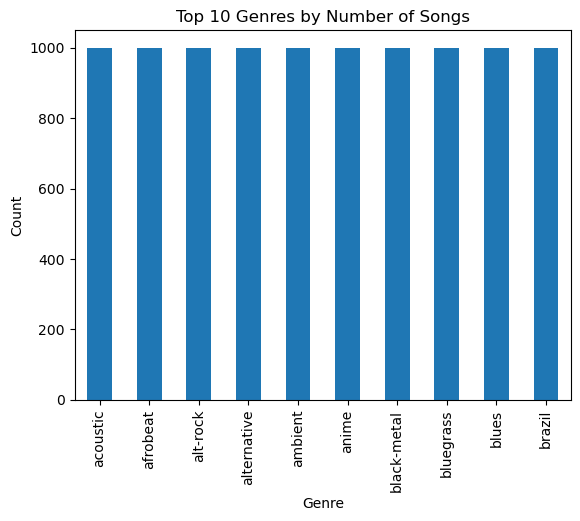

In [96]:
fig, ax = plt.subplots()

df['track_genre'].value_counts().head(10).plot.bar()

ax.set_title("Top 10 Genres by Number of Songs")
ax.set_xlabel("Genre")
ax.set_ylabel("Count")

plt.show()

## Analysis

### Overall Relationships
The scatter plots below show the overall relationship between audio features and popularity across the entire dataset. The relationships appear weak and widely dispersed, suggesting that no single feature strongly determines popularity when all genres are combined together.

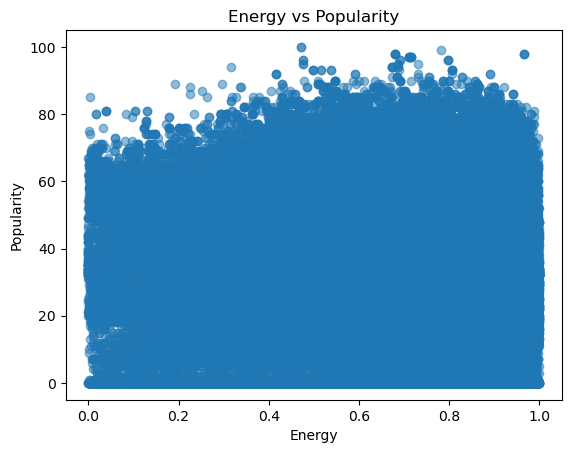

In [97]:
fig, ax = plt.subplots()

ax.scatter(df['energy'], df['popularity'], alpha = 0.5)

ax.set_title("Energy vs Popularity")
ax.set_xlabel("Energy")
ax.set_ylabel("Popularity")

plt.show()

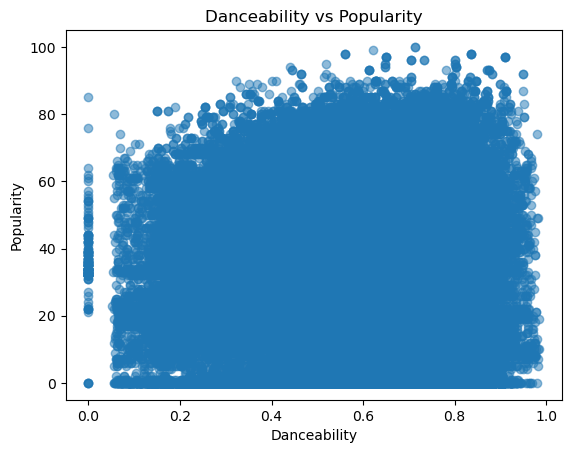

In [98]:
fig, ax = plt.subplots()

ax.scatter(df['danceability'], df['popularity'], alpha = 0.5)

ax.set_title("Danceability vs Popularity")
ax.set_xlabel("Danceability")
ax.set_ylabel("Popularity")

plt.show()

### Genre-Based Analysis
To better understand these relationships, the dataset is filtered to three genres: Pop, Rock, and Hip-Hop. Since the dataset is balanced across genres, these comparisons are not influenced by unequal sample sizes.

The scatter plots below show how the relationships between audio features and popularity look when genres are compared side by side. Differences in patterns begin to emerge. Hip-hop songs tend to cluster at higher energy levels, pop shows stronger connections to danceability, and rock shows greater variation in both features and popularity.

In [99]:
pop_df = df[df['track_genre'] == 'pop']
rock_df = df[df['track_genre'] == 'rock']
hiphop_df = df[df['track_genre'] == 'hip-hop']

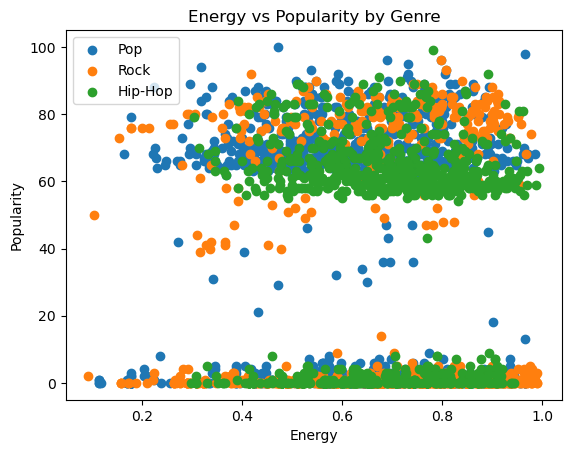

In [100]:
fig, ax = plt.subplots()

ax.scatter(pop_df['energy'], pop_df['popularity'], label='Pop')
ax.scatter(rock_df['energy'], rock_df['popularity'], label='Rock')
ax.scatter(hiphop_df['energy'], hiphop_df['popularity'], label='Hip-Hop')

ax.set_title("Energy vs Popularity by Genre")
ax.set_xlabel("Energy")
ax.set_ylabel("Popularity")

ax.legend()

plt.show()

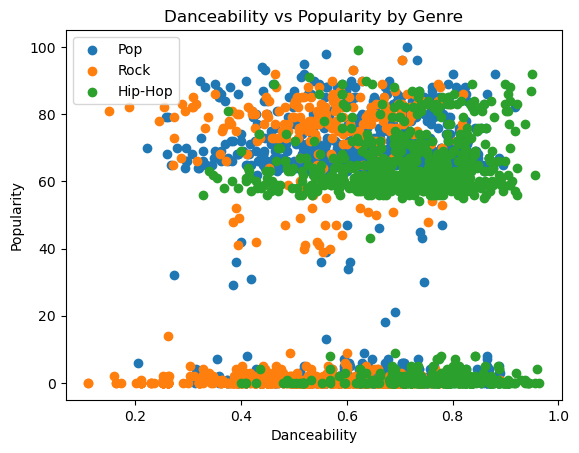

In [101]:
fig, ax = plt.subplots()

ax.scatter(pop_df['danceability'], pop_df['popularity'], label='Pop')
ax.scatter(rock_df['danceability'], rock_df['popularity'], label='Rock')
ax.scatter(hiphop_df['danceability'], hiphop_df['popularity'], label='Hip-Hop')

ax.set_title("Danceability vs Popularity by Genre")
ax.set_xlabel("Danceability")
ax.set_ylabel("Popularity")

ax.legend()

plt.show()

### Findings
The differences observed across genres suggest that the relationship between audio features and popularity varies depending on the characteristics of each genre. Hip-hop songs tend to cluster at higher energy levels, reflecting audience preferences for more intense and rhythm-driven music. Pop music appears to show stronger connections to danceability, aligning with its focus on mainstream appeal and accessibility. Rock shows greater variation in both energy and popularity, suggesting that its success depends more on specific stylistic elements rather than consistent patterns.

These findings directly address the research question: while audio features like energy and danceability relate to popularity, the relationship is relatively weak and varies across genres. No single audio feature strongly determines popularity. Instead, it is showing that multiple factors contribute to a song's success, and those factors differ by each genre.

The interactive dashboard below allows users to explore these relationships dynamically.

## Interactive Dashboard

The dashboard below goes beyond the static analysis above into an interactive experience designed for aspiring music creators and producers. The goal is to allow the audience to explore the core finding themselves which are, that the relationship between audio features and popularity is weak and varies across genres, rather than just being told about it.

Design decisions: The dropdown was chosen as the main control because it allows the user to switch between viewing all three genres together or focusing on one specific genre. This is intentional because starting with All Genres shows the overall weak relationship, and then selecting a specific genre reveals how the pattern shifts, which is exactly the story this project is trying to tell.

The conditional logic (if value == 'All') separates the two views clearly. When All Genres is selected, all three genres appear as separate colored traces so the user can directly compare them. When a specific genre is selected, both charts filter to that genre so the user can focus on its specific pattern.

Two charts are shown at the same time: energy vs popularity on top and danceability vs popularity on the bottom. This is because these are the two features central to the research question. Showing them simultaneously allows the user to compare both features at once rather than switching between them, which is more useful for the intended audience.

Every design decision is motivated by the research question and the needs of the audience.

In [102]:
app = Dash()

app.layout = html.Div([
    html.H1('Behind the Hit: Exploring Music Popularity',
            style={'color': 'white', 'fontFamily': 'Georgia, serif', 'textAlign': 'center'}),
    html.H3('How do audio features relate to song popularity across genres?',
            style={'color': '#a8c8f0', 'fontFamily': 'Georgia, serif', 'textAlign': 'center'}),

    dcc.Dropdown(
        options=[
            {'label': 'All Genres', 'value': 'All'},
            {'label': 'Pop', 'value': 'pop'},
            {'label': 'Rock', 'value': 'rock'},
            {'label': 'Hip-Hop', 'value': 'hip-hop'},
        ],
        value='All',
        id='genre_dropdown',
        style={'width': '50%', 'margin': 'auto'}
    ),

    dcc.Graph(id='header_fig'),

    html.Div([
        dcc.Graph(id='bottom_fig'),
    ])

], style={'backgroundColor': '#0a1628', 'padding': '30px'})


@callback(
    Output('header_fig', 'figure'),
    Output('bottom_fig', 'figure'),
    Input('genre_dropdown', 'value')
)
def update_fig(value):
    if value == 'All':
        pop_df = df[df['track_genre'] == 'pop']
        rock_df = df[df['track_genre'] == 'rock']
        hiphop_df = df[df['track_genre'] == 'hip-hop']

        header_fig = go.Figure(data=[
            go.Scatter(x=pop_df['energy'], y=pop_df['popularity'], mode='markers', name='Pop'),
            go.Scatter(x=rock_df['energy'], y=rock_df['popularity'], mode='markers', name='Rock'),
            go.Scatter(x=hiphop_df['energy'], y=hiphop_df['popularity'], mode='markers', name='Hip-Hop')
        ])
        header_fig.update_layout(
            title='Energy vs Popularity',
            xaxis_title='Energy',
            yaxis_title='Popularity'
        )

        bottom_fig = go.Figure(data=[
            go.Scatter(x=pop_df['danceability'], y=pop_df['popularity'], mode='markers', name='Pop'),
            go.Scatter(x=rock_df['danceability'], y=rock_df['popularity'], mode='markers', name='Rock'),
            go.Scatter(x=hiphop_df['danceability'], y=hiphop_df['popularity'], mode='markers', name='Hip-Hop')
        ])
        bottom_fig.update_layout(
            title='Danceability vs Popularity',
            xaxis_title='Danceability',
            yaxis_title='Popularity'
        )

    else:
        filtered_df = df[df['track_genre'] == value]

        header_fig = go.Figure(data=[
            go.Scatter(x=filtered_df['energy'], y=filtered_df['popularity'], mode='markers', name=value)
        ])
        header_fig.update_layout(
            title='Energy vs Popularity',
            xaxis_title='Energy',
            yaxis_title='Popularity'
        )

        bottom_fig = go.Figure(data=[
            go.Scatter(x=filtered_df['danceability'], y=filtered_df['popularity'], mode='markers', name=value)
        ])
        bottom_fig.update_layout(
            title='Danceability vs Popularity',
            xaxis_title='Danceability',
            yaxis_title='Popularity'
        )

    return header_fig, bottom_fig


if __name__ == '__main__':
    app.run(debug=True, port=8053)

## Limitations & Next Steps

This analysis is limited to three genres and two audio features, which means the findings may not generalise across the full dataset. Popularity scores on Spotify are also influenced by factors beyond audio features like marketing, release timing, and artist following. These are not present in this dataset.

Future work could expand the analysis to include more genres and features, apply statistical measures like correlation coefficients to represent the strength of relationships more clearly, and add external data like streaming counts or social media metrics to better understand what drives song popularity. 

Additionally, future improvements to the visualizations could include distinct markers/shapes for each genre like circles, triangles, and squares to improve accessibility and make the charts easier to read.